# 04 - Modeling
## Credit Risk Intelligence — Canadian Banking Project

## 1. Libraries & Setup

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load feature engineered dataset
df = pd.read_csv('../data/cs-training-features.csv')

## 2. Preparing Data for Modeling

In [3]:
# Drop non-numeric and target columns from features
X = df.drop(columns=['SeriousDlqin2yrs', 'age_group'])

# Define target variable
y = df['SeriousDlqin2yrs']

# Split into train and test sets — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size: {X_test.shape[0]}')

Train size: 114343
Test size: 28586


## 3. Baseline Model — Logistic Regression

In [4]:
# Train baseline logistic regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate model
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     26780
           1       0.60      0.14      0.23      1806

    accuracy                           0.94     28586
   macro avg       0.77      0.57      0.60     28586
weighted avg       0.92      0.94      0.92     28586

AUC-ROC: 0.7931


## 4. Main Model — Random Forest

In [5]:
# Train Random Forest with class_weight to handle imbalanced data
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate model
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     26780
           1       0.22      0.71      0.34      1806

    accuracy                           0.83     28586
   macro avg       0.60      0.77      0.62     28586
weighted avg       0.93      0.83      0.86     28586

AUC-ROC: 0.8609


## 5. Feature Importance

/var/folders/jx/_q0hlhjj65zcpy3pb78x177w0000gq/T/ipykernel_27007/2884122475.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature',


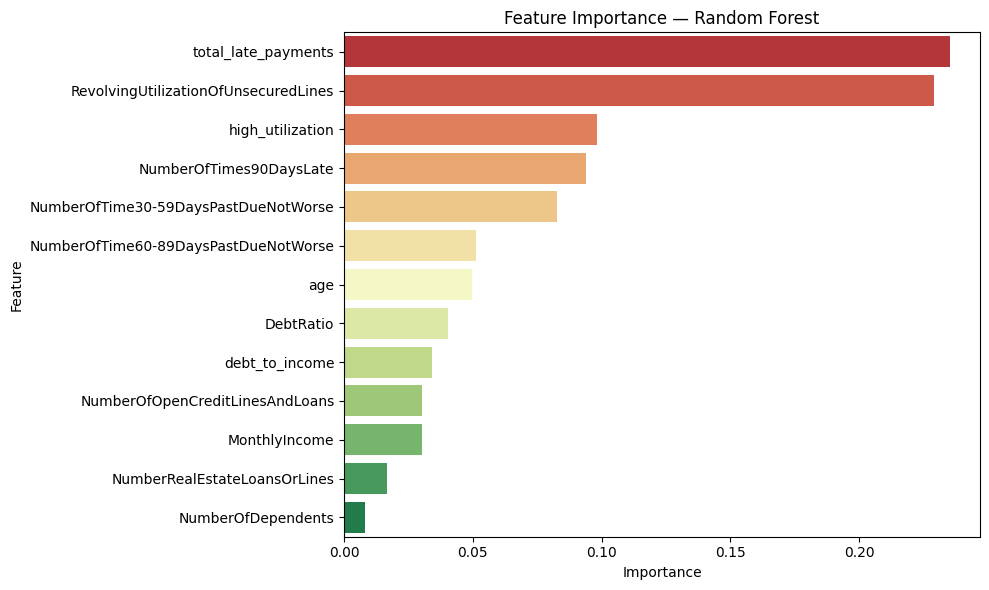

In [6]:
# Extract feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Visualize top features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', 
            palette='RdYlGn')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Saving Model Results

In [7]:
# Save feature importance for Power BI dashboard
feature_importance.to_csv('../data/feature_importance.csv', index=False)

# Save predictions with actual values and result types for Power BI
results = X_test.copy()
results['actual'] = y_test.values
results['predicted'] = y_pred_rf
results['probability'] = rf_model.predict_proba(X_test)[:, 1]

# Create result type column for business analysis
results['result_type'] = np.select(
    condlist=[
        (results['actual'] == 1) & (results['predicted'] == 1),
        (results['actual'] == 0) & (results['predicted'] == 0),
        (results['actual'] == 0) & (results['predicted'] == 1),
        (results['actual'] == 1) & (results['predicted'] == 0)
    ],
    choicelist=[
        'Hit (Defaulter)',
        'Hit (Good Payer)',
        'False Alarm',
        'Miss (Hidden Default)'
    ],
    default='Unknown'
)

results.to_csv('../data/model_results.csv', index=False)
print("Files saved successfully!")

Files saved successfully!


In [12]:
import pickle

# Save trained Random Forest model for Streamlit app
with open('../dashboard/model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved successfully!")

Model saved successfully!
